In [1]:
pip install torch torchvision numpy matplotlib tqdm seaborn scikit-learn

Note: you may need to restart the kernel to use updated packages.


In [2]:
#importation des modules
import torch
from torchvision.models import ResNet18_Weights
import torchvision.models as models
import numpy as np
from torchvision.transforms import transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader
from torch.utils.data import random_split    
import matplotlib.pyplot as plt
import torch.nn.functional as F
import torch.optim as optim
from tqdm import tqdm
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import StratifiedShuffleSplit
from torch.utils.data import Subset
from torch.utils.data import WeightedRandomSampler
from collections import Counter


In [4]:
#attention, donnees equilibrees? AUC COMPARABle? oui avec l'AUC
#attention également aux conventions : classe positive =1 classe normale/négative = 0
#génération des données équilibrées

#standardisation de la transformation des images pour coller au modèle restnet18
transform = transforms.Compose([
    transforms.Resize((700,700)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])])
data_set=ImageFolder(root="/home/onyxia/work/dataset_vindr", transform=transform)
label=np.array(data_set.targets)
print(len(label))
print(label.sum()/len(label))

bs=64
test_loader = DataLoader(
    data_set, 
    batch_size=bs,       # Augmente le batch_size si possible (ex: 64 ou 128)
    shuffle=False, 
    num_workers=4,       # <--- ESSENTIEL : utilise plusieurs cœurs CPU
    pin_memory=True      # <--- Accélère le transfert CPU vers GPU
)
#test_loader = DataLoader(data_set, batch_size=bs, shuffle=False)


9999
0.32963296329632963


In [ ]:
#extraction des résultats sur test set ou sur val set
import torch.nn.functional as F
model = models.resnet18(weights=ResNet18_Weights.DEFAULT)
num_class=2
model.fc = torch.nn.Linear(model.fc.in_features, num_class)
model.load_state_dict(torch.load("best_resnet18_model_ordonnanceur.pth"))

device=torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
model.to(device)
print(device)

choose_data=test_loader  #choisir entre "test" ou "val"
model.eval()

all_predictions = []
all_labels= []
all_probabilities = []

with torch.no_grad():
    for inputs, labels in tqdm(choose_data):
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        probabilities = F.softmax(outputs, dim=1)
        _,preds=torch.max(outputs,1)
        all_predictions.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

        #pour le calcul de l'AUC, on peut aussi stocker les probabilités
        positive_class_probs = probabilities[:, 1].cpu().numpy()
        all_probabilities.extend(positive_class_probs)
        # Traitez les probabilités comme nécessaire

predictions_np=np.array(all_predictions)
labels_np=np.array(all_labels)
probabilities_np=np.array(all_probabilities)


accuracy = np.mean(predictions_np == labels_np)
print(f'Test_Accuracy : {accuracy*100:.4f}%')


cuda:0


100%|██████████| 157/157 [02:11<00:00,  1.20it/s]

Test_Accuracy : 33.0633%


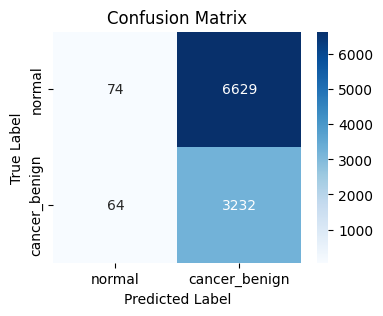

In [ ]:
#matrice de confusion

class_names = ['normal', 'cancer_benign']
cm = confusion_matrix(labels_np, predictions_np)

plt.figure(figsize=(4, 3))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')   
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()



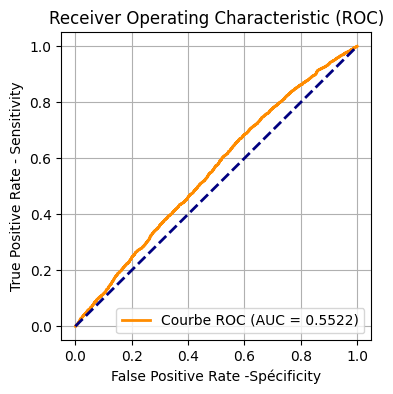

In [ ]:
#calcul de l'AUC et de la courbe ROC
from sklearn.metrics import roc_curve, auc
fpr, tpr, thresholds = roc_curve(labels_np, probabilities_np, pos_label=0)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4,4))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Courbe ROC (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')

plt.xlabel('False Positive Rate -Spécificity')
plt.ylabel('True Positive Rate - Sensitivity')
plt.title('Receiver Operating Characteristic (ROC)')
plt.legend(loc="lower right")
plt.grid(True)
plt.show()

